In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cftime
import warnings
from datetime import datetime

warnings.filterwarnings(action = 'ignore', category = RuntimeWarning)

In [2]:
casename = 'test_US-SPR_ICB1850CNRDCTCBC_ad_spinup'
file_list = [os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', 
                         f'{casename}.clm2.h2.{y:04g}-01-01-00000.nc') for y in [28, 29, 30, 31, 33]]

hr = xr.open_mfdataset(file_list, decode_times=False)
hr['time'] = xr.decode_cf(hr, decode_times=True, decode_coords=True)['time']

file_list_env = [os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', 
                         f'{casename}.clm2.h1.{y:04g}-01-01-00000.nc') for y in [28, 29, 30, 31, 33]]
hr2 = xr.open_mfdataset(file_list_env, decode_times=False)
hr2['time'] = xr.decode_cf(hr2, decode_times=True, decode_coords=True)['time']

Text(0.5, 1.0, 'TSOI Layer 3')

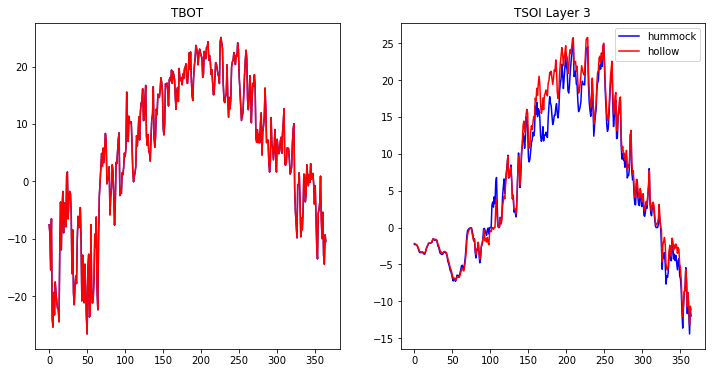

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (12,6), sharex = True)
ax = axes[0]
ax.plot((hr2['TBOT'] - 273.15).resample(time = '1D').mean()[:365, 0], '-b', label = 'hummock')
ax.plot((hr2['TBOT'] - 273.15).resample(time = '1D').mean()[:365, 1], '-r', label = 'hollow')
ax.set_title('TBOT')
ax = axes[1]
ax.plot((hr2['TSOI'] - 273.15).resample(time = '1D').mean()[:365, 2, 0], '-b', label = 'hummock')
ax.plot((hr2['TSOI'] - 273.15).resample(time = '1D').mean()[:365, 2, 1], '-r', label = 'hollow')
ax.legend()
ax.set_title('TSOI Layer 3')

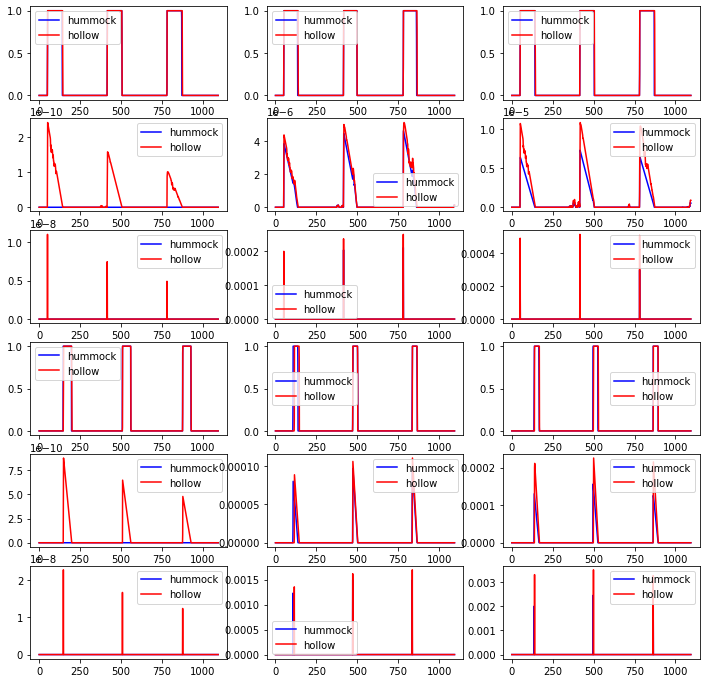

In [27]:
fig, axes = plt.subplots(6, 3, figsize = (12,12))
for i, pft in enumerate([2, 3, 11]):
    temp = hr['ONSET_FLAG_ROOT'].resample(time = '1D').mean().compute()
    ax = axes[0, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    temp = hr['FROOTC_XFER_TO_FROOTC'].resample(time = '1D').mean().compute()
    ax = axes[1, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    temp = hr['FROOTC_STORAGE_TO_XFER'].resample(time = '1D').mean().compute()
    ax = axes[2, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    temp = hr['ONSET_FLAG'].resample(time = '1D').mean().compute()
    ax = axes[3, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    temp = hr['LEAFC_XFER_TO_LEAFC'].resample(time = '1D').mean().compute()
    ax = axes[4, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    temp = hr['LEAFC_STORAGE_TO_XFER'].resample(time = '1D').mean().compute()
    ax = axes[5, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

In [4]:
# Two problems: (1) imbalance only happens in the years 

offset = 365 * 24 * 1
pft = 11
yearsize = 365 * 24
temp = np.where(hr['ONSET_FLAG_ROOT'][offset:(offset+yearsize), pft] > 0.1)[0]
temp2 = np.where(hr['ONSET_FLAG'][offset:(offset+yearsize), pft] > 0.1)[0]
temp, temp2

(array([1214, 1215, 1216, ..., 3309, 3310, 3311]),
 array([3122, 3123, 3124, 3125, 3126, 3127, 3128, 3129, 3130, 3131, 3132,
        3133, 3134, 3135, 3136, 3137, 3138, 3139, 3140, 3141, 3142, 3143,
        3144, 3145, 3146, 3147, 3148, 3149, 3150, 3151, 3152, 3153, 3154,
        3155, 3156, 3157, 3158, 3159, 3160, 3161, 3162, 3163, 3164, 3165,
        3166, 3167, 3168, 3169, 3170, 3171, 3172, 3173, 3174, 3175, 3176,
        3177, 3178, 3179, 3180, 3181, 3182, 3183, 3184, 3185, 3186, 3187,
        3188, 3189, 3190, 3191, 3192, 3193, 3194, 3195, 3196, 3197, 3198,
        3199, 3200, 3201, 3202, 3203, 3204, 3205, 3206, 3207, 3208, 3209,
        3210, 3211, 3212, 3213, 3214, 3215, 3216, 3217, 3218, 3219, 3220,
        3221, 3222, 3223, 3224, 3225, 3226, 3227, 3228, 3229, 3230, 3231,
        3232, 3233, 3234, 3235, 3236, 3237, 3238, 3239, 3240, 3241, 3242,
        3243, 3244, 3245, 3246, 3247, 3248, 3249, 3250, 3251, 3252, 3253,
        3254, 3255, 3256, 3257, 3258, 3259, 3260, 3261, 3262,

In [196]:
hr['time'].to_index()[(offset+temp[-1])], hr['time'].to_index()[(offset+temp2[-1])]

(cftime.DatetimeNoLeap(29, 5, 18, 22, 59, 31, 875000),
 cftime.DatetimeNoLeap(29, 6, 10, 1, 0, 28, 125000))

In [197]:
hr['FROOTC_XFER_TO_FROOTC'][(offset+temp[0]-1):(offset+temp[-1]+2), pft].values, hr['LEAFC_XFER_TO_LEAFC'][(offset+temp2[0]-1):(offset+temp2[-1]+2), pft].values

(array([ 2.0916382e-08,  2.7289911e-12,  7.3905803e-06, ...,
         8.4265181e-09, -1.9351303e-09,  0.0000000e+00], dtype=float32),
 array([0.00000000e+00, 0.00000000e+00, 1.63930090e-04, 1.63701407e-04,
        1.63472723e-04, 1.63244040e-04, 1.63015342e-04, 1.62786659e-04,
        1.62557975e-04, 1.62329292e-04, 1.62100623e-04, 1.61871940e-04,
        1.61643256e-04, 1.61414573e-04, 1.61185904e-04, 1.60957221e-04,
        1.60728552e-04, 1.60499883e-04, 1.60271200e-04, 1.60042531e-04,
        1.59813862e-04, 1.59585194e-04, 1.59356525e-04, 1.59127856e-04,
        1.58899187e-04, 1.58670518e-04, 1.58441864e-04, 1.58213195e-04,
        1.57984527e-04, 1.57755872e-04, 1.57527204e-04, 1.57298549e-04,
        1.57069895e-04, 1.56841241e-04, 1.56612572e-04, 1.56383918e-04,
        1.56155264e-04, 1.55926609e-04, 1.55697970e-04, 1.55469315e-04,
        1.55240661e-04, 1.55012007e-04, 1.54783367e-04, 1.54554713e-04,
        1.54326073e-04, 1.54097434e-04, 1.53868779e-04, 1.53640140e-04,
  

In [198]:
hr['FROOTC_STORAGE_TO_XFER'][(offset+temp[0]-2):(offset+temp[-1]+2), pft].values, hr['LEAFC_STORAGE_TO_XFER'][(offset+temp2[0]-2):(offset+temp2[-1]+2), pft].values

(array([0.000000e+00, 2.947317e-09, 7.978147e-03, ..., 0.000000e+00,
        0.000000e+00, 0.000000e+00], dtype=float32),
 array([0.      , 0.      , 0.058933, 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.  

In [205]:
hr['FROOTC_XFER_TO_FROOTC'][(offset+temp[0]-1):(offset+temp[-1]+2), pft].sum().values, hr['LEAFC_XFER_TO_LEAFC'][(offset+temp2[0]-1):(offset+temp2[-1]+2), pft].sum().values

(array(0.00796507, dtype=float32), array(0.05890073, dtype=float32))

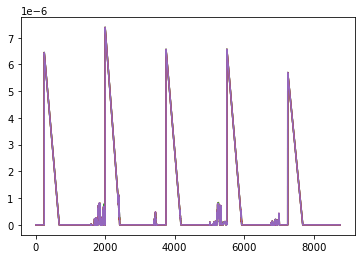

In [5]:
plt.plot(hr['FROOTC_XFER_TO_FROOTC'][:, pft].values.reshape(yearsize, -1))

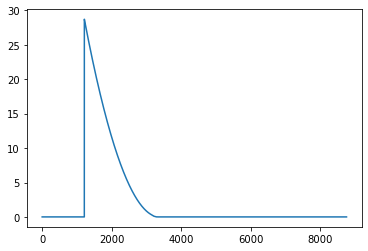

In [10]:
plt.plot(hr['FROOTC_XFER'][offset:(offset+yearsize), pft].values.reshape(yearsize, -1))

In [11]:
np.where(hr['FROOTC_XFER'][offset:(offset+yearsize), pft] < 0.)

(array([3310]),)

In [19]:
negative = offset + 3310
hr['ONSET_COUNTER_ROOT'][negative-1, pft].values, hr['ONSET_COUNTER_ROOT'][negative, pft].values, hr['ONSET_COUNTER_ROOT'][negative+1, pft].values, hr['ONSET_COUNTER_ROOT'][negative+2, pft].values

(array(17025.97070312), array(10973.98632812), array(4921.17236328), array(0.))

In [33]:
hr['time'][negative].values

array(cftime.DatetimeNoLeap(29, 5, 18, 22, 0, 28, 125000), dtype=object)

In [23]:
hr['FROOTC_XFER'][negative-1, pft].values, hr['FROOTC_XFER'][negative, pft].values, hr['FROOTC_XFER'][negative+1, pft].values, hr['FROOTC_XFER'][negative+2, pft].values

(array(2.75034545e-05),
 array(-2.83200484e-06),
 array(4.13445468e-06),
 array(0.))

In [30]:
hr['ONSET_FROOT_FNMIN'][negative, pft].values, hr['ONSET_FROOT_FW'][negative, pft].values

(array(1.68110693), array(1.))

In [28]:
2 / hr['ONSET_COUNTER_ROOT'][negative, pft].values * hr['ONSET_FROOT_FNMIN'][negative, pft].values * hr['ONSET_FROOT_FW'][negative, pft].values, 1/3600

(0.00030638035709999154, 0.0002777777777777778)

In [25]:
hr['FROOTC_XFER_TO_FROOTC'][negative-1, pft].values, hr['FROOTC_XFER_TO_FROOTC'][negative, pft].values, hr['FROOTC_XFER_TO_FROOTC'][negative+1, pft].values, hr['FROOTC_XFER_TO_FROOTC'][negative+2, pft].values

(array(1.8305732e-08),
 array(8.42651815e-09),
 array(-1.93513028e-09),
 array(0.))

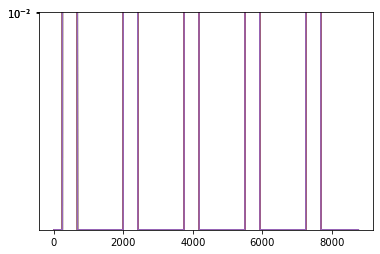

In [228]:
plt.plot(hr['ONSET_COUNTER_ROOT'][:, pft].values.reshape(yearsize, -1))
plt.gca().set_ylim([0, 0.1])
plt.gca().set_yscale('log')

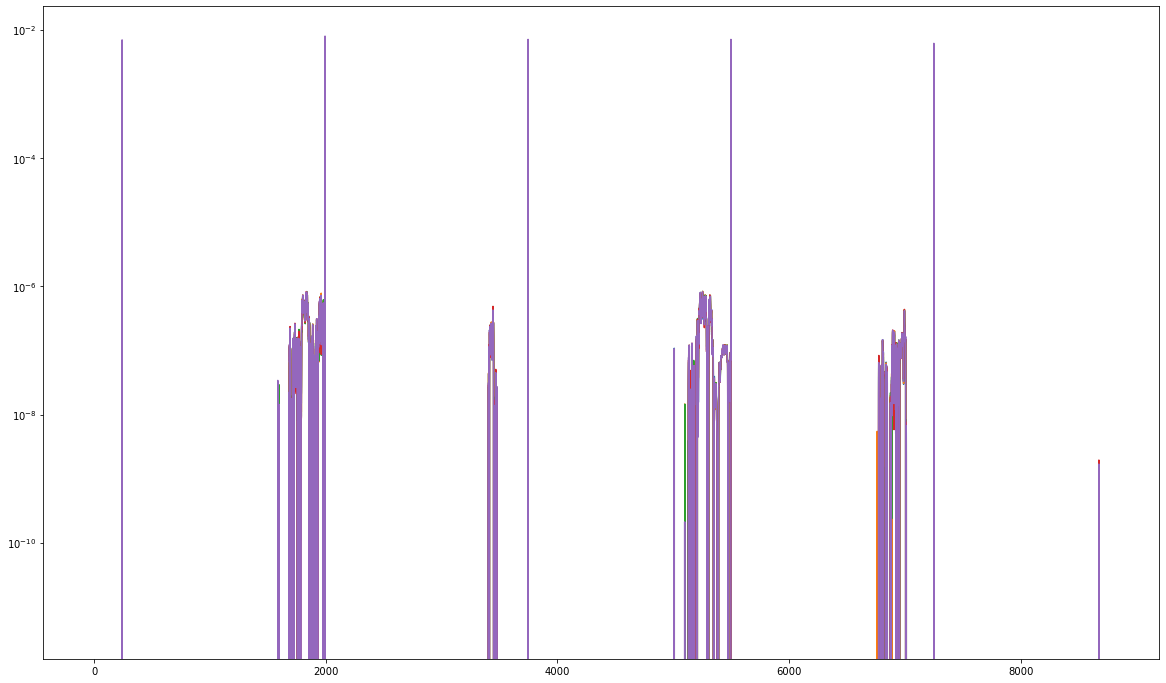

In [222]:
plt.figure(figsize = (20, 12))
plt.plot(hr['FROOTC_STORAGE_TO_XFER'][:, pft].values.reshape(yearsize, -1))
plt.gca().set_yscale('log')

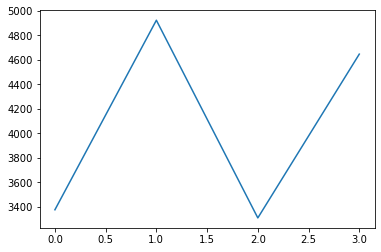

In [232]:
plt.plot(hr['ONSET_COUNTER_ROOT'][hr['FROOTC_XFER_TO_FROOTC'][:, pft] < 0., pft])

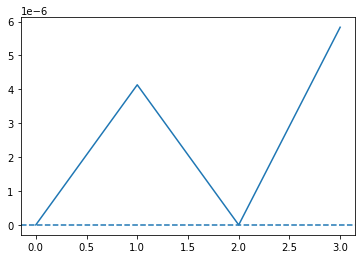

In [236]:
plt.plot(hr['FROOTC_XFER'][hr['FROOTC_XFER_TO_FROOTC'][:, pft] < 0., pft])
plt.axhline(0, ls = '--')

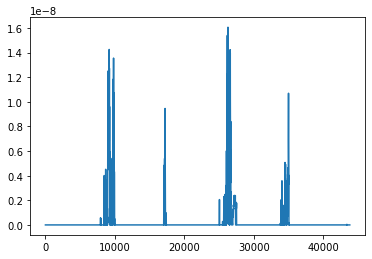

In [238]:
plt.plot(hr['BGTR'][:, pft])

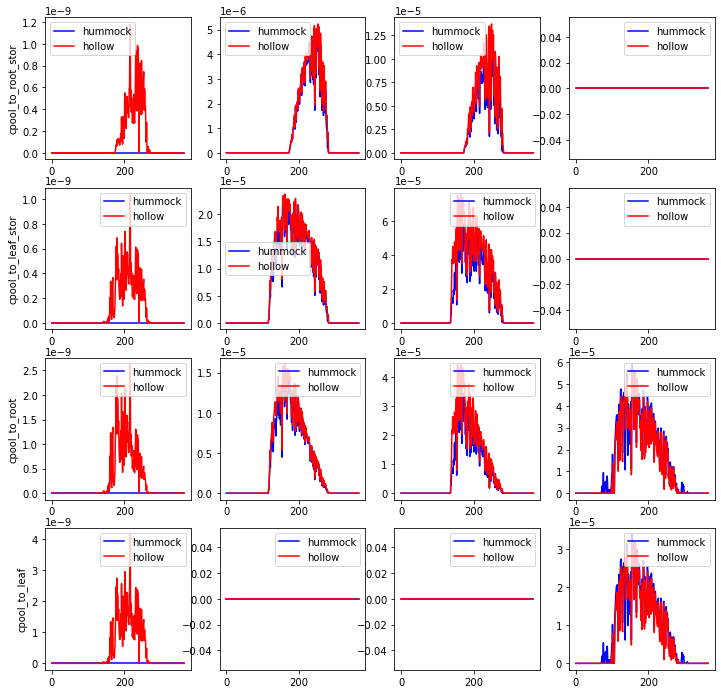

In [12]:
fig, axes = plt.subplots(4, 4, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11, 12]):
    ax = axes[0, i]
    ax.plot(hr['CPOOL_TO_FROOTC_STORAGE'].resample(time = '1D').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_FROOTC_STORAGE'].resample(time = '1D').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('cpool_to_root_stor')

    ax = axes[1, i]
    ax.plot(hr['CPOOL_TO_LEAFC_STORAGE'].resample(time = '1D').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_LEAFC_STORAGE'].resample(time = '1D').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()

    if i == 0:
        ax.set_ylabel('cpool_to_leaf_stor')

    ax = axes[2, i]
    ax.plot(hr['CPOOL_TO_FROOTC'].resample(time = '1D').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_FROOTC'].resample(time = '1D').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('cpool_to_root')

    ax = axes[3, i]
    ax.plot(hr['CPOOL_TO_LEAFC'].resample(time = '1D').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_LEAFC'].resample(time = '1D').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()

    if i == 0:
        ax.set_ylabel('cpool_to_leaf')

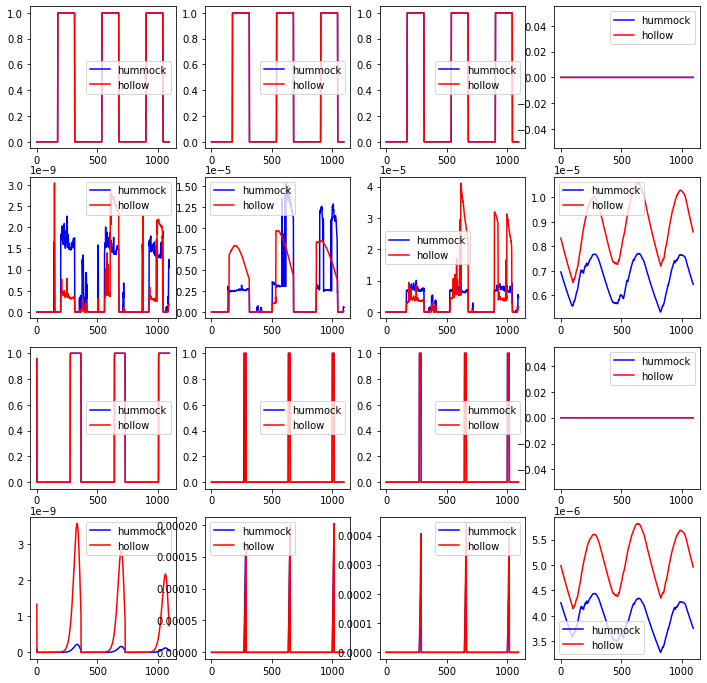

In [24]:
fig, axes = plt.subplots(4, 4, figsize = (12,12))
for i, pft in enumerate([2, 3, 11, 12]):
    ax = axes[0, i]
    ax.plot(hr['OFFSET_FLAG_ROOT'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_FLAG_ROOT'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['FROOTC_TO_LITTER'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC_TO_LITTER'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['OFFSET_FLAG'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_FLAG'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    #ax.set_xlim([268, 295])

    ax = axes[3, i]
    ax.plot(hr['LEAFC_TO_LITTER'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['LEAFC_TO_LITTER'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    #ax.set_xlim([268, 295])

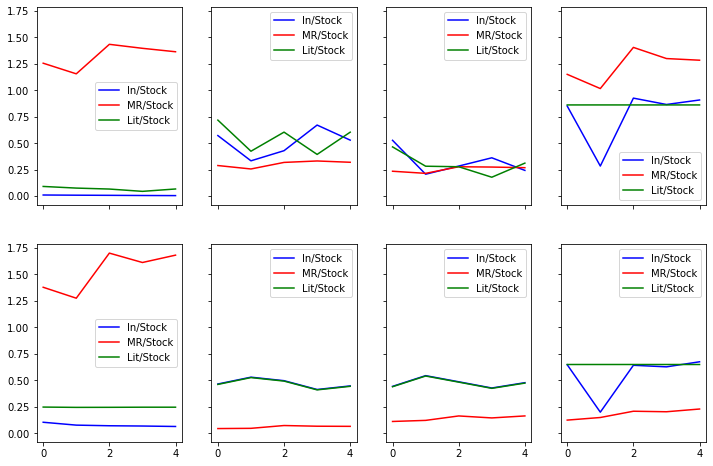

In [14]:
fig, axes = plt.subplots(2, 4, figsize = (12, 8), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11, 12]):

    frootc = hr['FROOTC'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
             hr['FROOTC'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    frootc_stor = hr['FROOTC_STORAGE'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
                  hr['FROOTC_STORAGE'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    frootc_alloc = hr['FROOTC_ALLOC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                   hr['FROOTC_ALLOC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_mr = hr['FROOT_MR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['FROOT_MR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_gr = hr['TRANSFER_FROOT_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['TRANSFER_FROOT_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_gr2 = hr['CPOOL_FROOT_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                 hr['CPOOL_FROOT_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_lit = hr['FROOTC_TO_LITTER'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                 hr['FROOTC_TO_LITTER'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    leafc = hr['LEAFC'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
            hr['LEAFC'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    leafc_stor = hr['LEAFC_STORAGE'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
                 hr['LEAFC_STORAGE'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    leafc_alloc = hr['LEAFC_ALLOC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                  hr['LEAFC_ALLOC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_mr = hr['LEAF_MR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
               hr['LEAF_MR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_gr = hr['TRANSFER_LEAF_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
               hr['TRANSFER_LEAF_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_gr2 = hr['CPOOL_LEAF_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['CPOOL_LEAF_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_lit = hr['LEAFC_TO_LITTER'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['LEAFC_TO_LITTER'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    ax = axes[0, i]
    ax.plot(frootc_alloc * 24 * 3600 / (frootc + frootc_stor), '-b', label = 'In/Stock')
    ax.plot((frootc_mr)  * 24 * 3600 / (frootc + frootc_stor), '-r', label = 'MR/Stock')
    # ax.plot((frootc_gr2 + frootc_gr) / (frootc_alloc), '-', color = 'magenta', label = 'Gr/In')
    ax.plot((frootc_lit)  * 24 * 3600 / (frootc + frootc_stor), '-g', label = 'Lit/Stock')
    ax.legend()

    ax = axes[1, i]
    ax.plot(leafc_alloc  * 24 * 3600 / (leafc + leafc_stor), '-b', label = 'In/Stock')
    ax.plot((leafc_mr)  * 24 * 3600 / (leafc + leafc_stor), '-r', label = 'MR/Stock')
    # ax.plot((leafc_gr2 + leafc_gr) / (leafc_alloc), '-', color = 'magenqta', label = 'Gr/In')
    ax.plot((leafc_lit)  * 24 * 3600 / (leafc + leafc_stor), '-g', label = 'Lit/Stock')
    ax.legend()

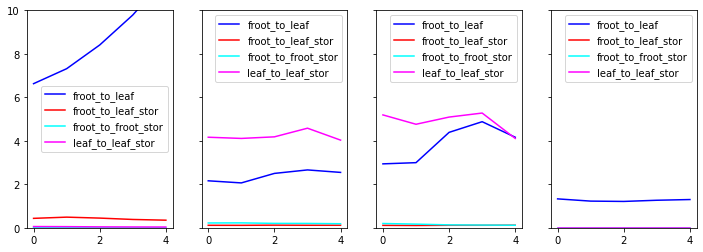

In [15]:
# root to leaf
fig, axes = plt.subplots(1, 4, figsize = (12, 4), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11, 12]):

    frootc = hr['FROOTC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
             hr['FROOTC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_stor = hr['FROOTC_STORAGE'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                  hr['FROOTC_STORAGE'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    leafc = hr['LEAFC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
            hr['LEAFC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_stor = hr['LEAFC_STORAGE'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                 hr['LEAFC_STORAGE'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    ax = axes.flat[i]
    ax.plot(frootc / leafc, '-b', label = 'froot_to_leaf')
    ax.plot(frootc_stor / leafc_stor, '-r', label = 'froot_to_leaf_stor')
    ax.plot(frootc_stor / frootc, '-', color = 'cyan', label = 'froot_to_froot_stor')
    ax.plot(leafc_stor / leafc, '-', color = 'magenta', label = 'leaf_to_leaf_stor')
    ax.legend()
    ax.set_ylim([0, 10])

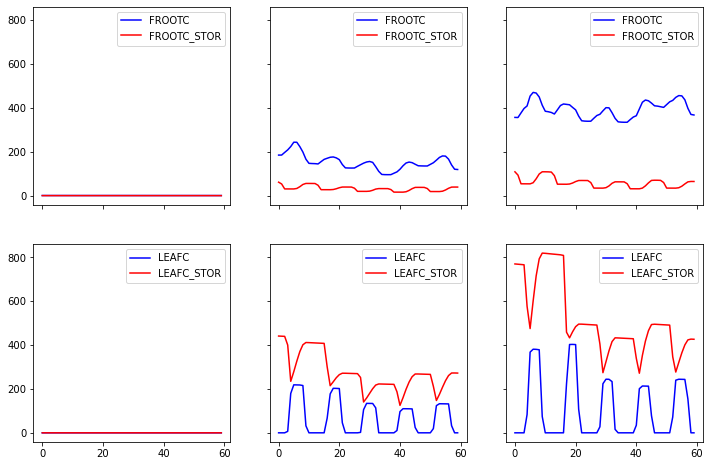

In [16]:
fig, axes = plt.subplots(2, 3, figsize = (12, 8), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11]):

    frootc = hr['FROOTC'].resample(time = '1M').mean()[:, pft] * 0.64 + \
             hr['FROOTC'].resample(time = '1M').mean()[:, pft + 17] * 0.36
    frootc_stor = hr['FROOTC_STORAGE'].resample(time = '1M').mean()[:, pft] * 0.64 + \
                  hr['FROOTC_STORAGE'].resample(time = '1M').mean()[:, pft + 17] * 0.36

    leafc = hr['LEAFC'].resample(time = '1M').mean()[:, pft] * 0.64 + \
            hr['LEAFC'].resample(time = '1M').mean()[:, pft + 17] * 0.36
    leafc_stor = hr['LEAFC_STORAGE'].resample(time = '1M').mean()[:, pft] * 0.64 + \
                 hr['LEAFC_STORAGE'].resample(time = '1M').mean()[:, pft + 17] * 0.36

    ax = axes[0, i]
    ax.plot(frootc, '-b', label = 'FROOTC')
    ax.plot(frootc_stor, '-r', label = 'FROOTC_STOR')
    ax.legend()

    ax = axes[1, i]
    ax.plot(leafc, '-b', label = 'LEAFC')
    ax.plot(leafc_stor, '-r', label = 'LEAFC_STOR')
    ax.legend()

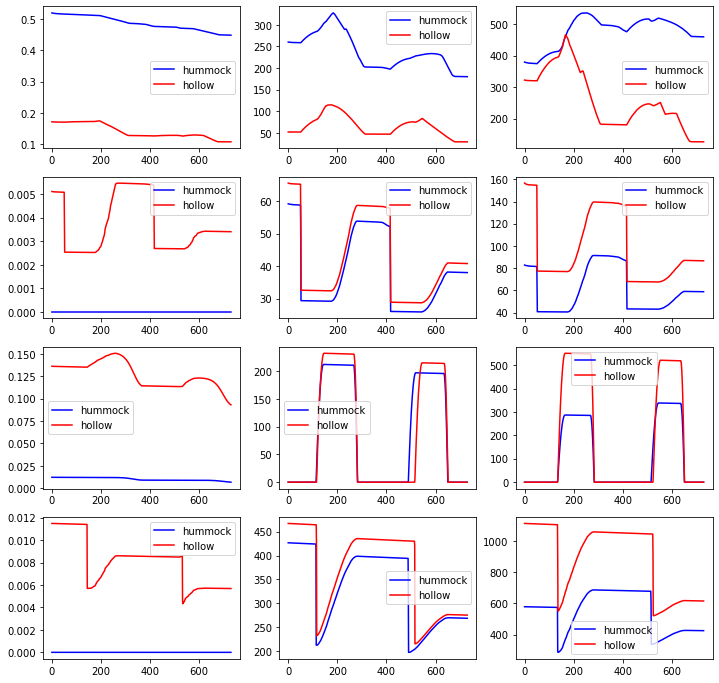

In [17]:
# carbon stock
fig, axes = plt.subplots(4, 3, figsize = (12,12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['FROOTC'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['FROOTC_STORAGE'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC_STORAGE'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['LEAFC'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['LEAFC'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[3, i]
    ax.plot(hr['LEAFC_STORAGE'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['LEAFC_STORAGE'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

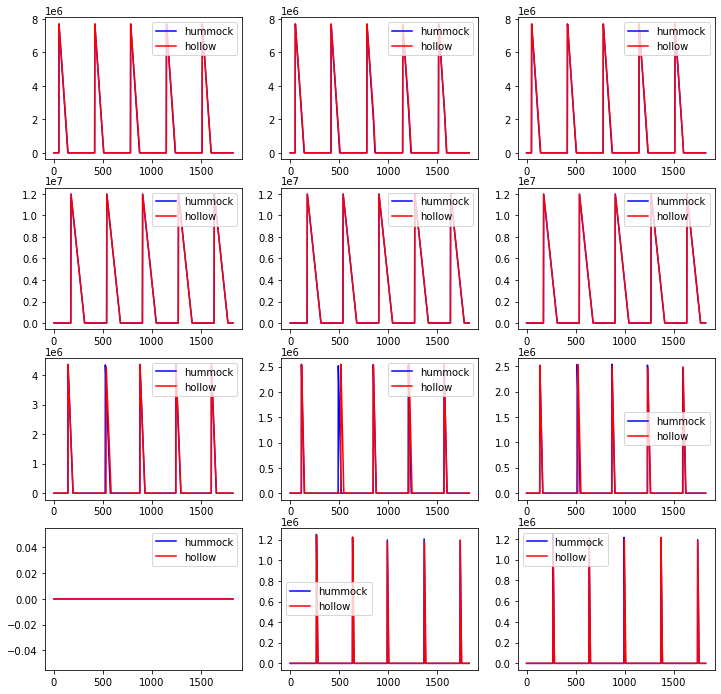

In [18]:
fig, axes = plt.subplots(4, 3, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['ONSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['OFFSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['ONSET_COUNTER'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_COUNTER'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[3, i]
    ax.plot(hr['OFFSET_COUNTER'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_COUNTER'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

KeyboardInterrupt: 

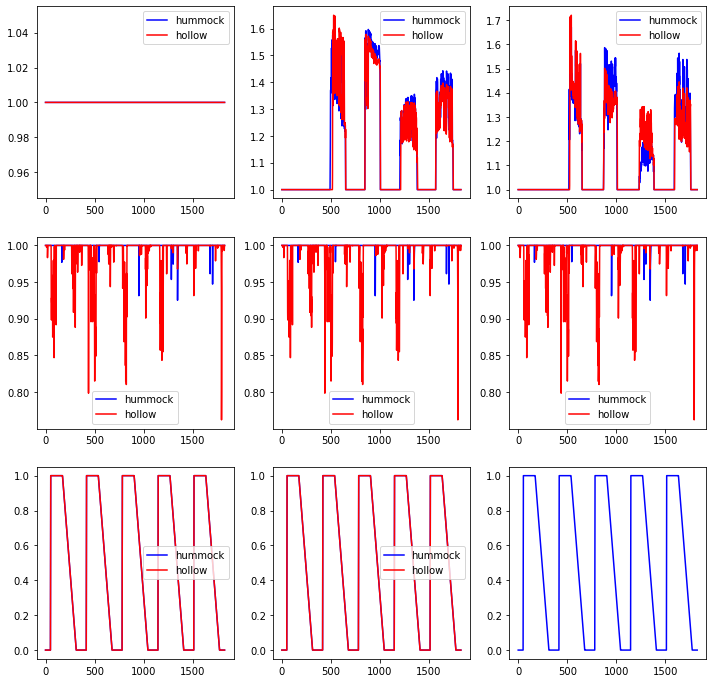

In [19]:
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['ONSET_FROOT_FNMIN'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_FROOT_FNMIN'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['ONSET_FROOT_FW'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_FROOT_FW'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['FCUR_DYN'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['FCUR_DYN'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

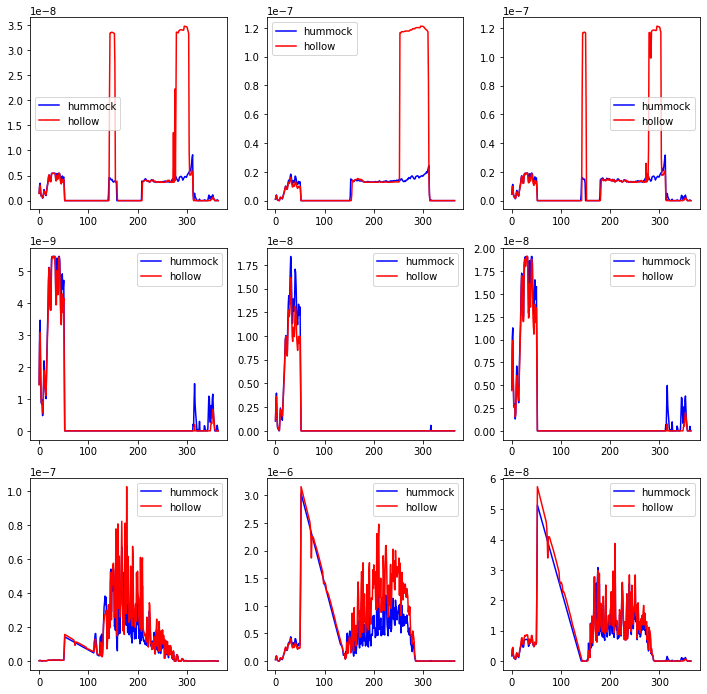

In [ ]:
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['BGLFR_FROOT'].resample(time = '1D').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['BGLFR_FROOT'].resample(time = '1D').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['BGTR'].resample(time = '1D').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['BGTR'].resample(time = '1D').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['FROOTC_ALLOC'].resample(time = '1D').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC_ALLOC'].resample(time = '1D').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()

In [ ]:
hr.close()
hr2.close()